In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

c:\Users\Saikat Maiti\Desktop\Music recommendation\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import transformers

print("Transformers Version:", transformers.__version__)
print("GPU Available:", torch.cuda.is_available())

Transformers Version: 5.11.0
GPU Available: False


In [3]:
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

In [4]:
id2label = label_map
label2id = {v: k for k, v in label_map.items()}

In [5]:
train_df = pd.read_csv(
    r"C:\Users\Saikat Maiti\Desktop\Music recommendation\text\data\training.csv"
)

val_df = pd.read_csv(
    r"C:\Users\Saikat Maiti\Desktop\Music recommendation\text\data\validation.csv"
)

test_df = pd.read_csv(
    r"C:\Users\Saikat Maiti\Desktop\Music recommendation\text\data\test.csv"
)

In [6]:
train_df["label"] = train_df["label"].astype(int)
val_df["label"] = val_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

In [7]:
print("Train Labels:", sorted(train_df["label"].unique()))
print("Validation Labels:", sorted(val_df["label"].unique()))
print("Test Labels:", sorted(test_df["label"].unique()))

Train Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Test Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [8]:
assert set(train_df["label"]).issubset({0, 1, 2, 3, 4,5})
assert set(val_df["label"]).issubset({0, 1, 2, 3, 4,5})
assert set(test_df["label"]).issubset({0, 1, 2, 3, 4,5})

In [9]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [10]:
train_encodings = tokenizer(
    list(train_df["text"]),
    truncation=True,
    padding=True,
    max_length=64,
)

In [11]:
val_encodings = tokenizer(
    list(val_df["text"]),
    truncation=True,
    padding=True,
    max_length=64,
)

In [12]:
test_encodings = tokenizer(
    list(test_df["text"]),
    truncation=True,
    padding=True,
    max_length=64,
)

In [13]:
class EmotionDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [14]:
train_dataset = EmotionDataset(
    train_encodings,
    train_df["label"]
)

In [15]:
val_dataset = EmotionDataset(
    val_encodings,
    val_df["label"]
)

In [16]:
test_dataset = EmotionDataset(
    test_encodings,
    test_df["label"]
)

In [17]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2226.00it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
def compute_metrics(pred):

    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [19]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_dir="./logs",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [21]:
trainer.train()

c:\Users\Saikat Maiti\Desktop\Music recommendation\myenv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.265503,0.270565,0.926500,0.931196,0.926500,0.927357
2,0.156767,0.175008,0.946500,0.946583,0.946500,0.946515


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.45it/s]
c:\Users\Saikat Maiti\Desktop\Music recommendation\myenv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.72s/it]


TrainOutput(global_step=8000, training_loss=0.2962167282104492, metrics={'train_runtime': 6212.7159, 'train_samples_per_second': 5.151, 'train_steps_per_second': 1.288, 'total_flos': 529907392512000.0, 'train_loss': 0.2962167282104492, 'epoch': 2.0})

In [22]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

c:\Users\Saikat Maiti\Desktop\Music recommendation\myenv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [23]:
precision, recall, f1, _ = precision_recall_fscore_support(
    test_df["label"],
    preds,
    average="weighted"
)

accuracy = accuracy_score(
    test_df["label"],
    preds
)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Accuracy : 0.9325
Precision: 0.9328515149313195
Recall   : 0.9325
F1 Score : 0.9325494186360546


In [24]:
cm = confusion_matrix(
    test_df["label"],
    preds
)

In [25]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ]
)

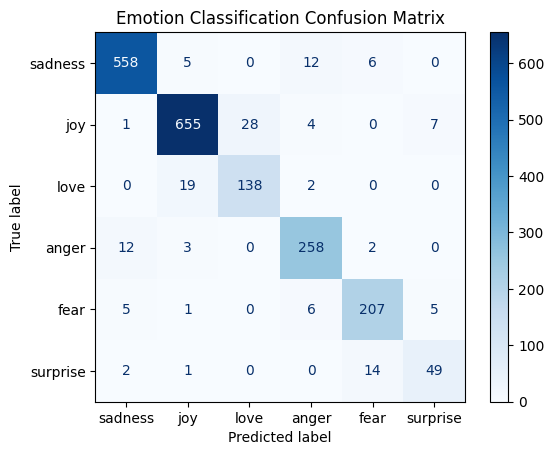

In [26]:
disp.plot(cmap=plt.cm.Blues)

plt.title("Emotion Classification Confusion Matrix")
plt.show()

In [30]:
tokenizer = DistilBertTokenizer.from_pretrained("saved_model1")
model = DistilBertForSequenceClassification.from_pretrained("saved_model")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2048.63it/s]


In [31]:
def predict_emotion(text):

    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64,
    )

    inputs = {
        k: v.to(model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(
        outputs.logits,
        dim=1
    )

    pred = torch.argmax(
        probs,
        dim=1
    ).item()

    confidence = probs[0][pred].item()

    return label_map[pred], confidence

In [32]:
examples = [
    "I am extremely happy today!",
    "I miss my best friend so much.",
    "I truly love spending time with my family.",
    "I am furious with what happened.",
    "I am scared to walk alone at night."
]

for sentence in examples:
    emotion, score = predict_emotion(sentence)
    print(f"\nText: {sentence}")
    print(f"Predicted Emotion: {emotion}")
    print(f"Confidence: {score:.4f}")


Text: I am extremely happy today!
Predicted Emotion: joy
Confidence: 0.9997

Text: I miss my best friend so much.
Predicted Emotion: sadness
Confidence: 0.5817

Text: I truly love spending time with my family.
Predicted Emotion: love
Confidence: 0.9981

Text: I am furious with what happened.
Predicted Emotion: anger
Confidence: 0.9998

Text: I am scared to walk alone at night.
Predicted Emotion: fear
Confidence: 0.9998


In [29]:
trainer.save_model("saved_model")
tokenizer.save_pretrained("saved_model1")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.76s/it]


('saved_model1\\tokenizer_config.json', 'saved_model1\\tokenizer.json')